LOADING MODELS

Loaded 6 models:
  ✓ XGBoost                XGBClassifier
  ✓ Random Forest          RandomForestClassifier
  ✓ SVM                    Pipeline
  ✓ Logistic Regression    Pipeline
  ✓ KNN                    Pipeline
  ✓ Gradient Boosting      GradientBoostingClassifier

LOADING WESAD
data/WESAD\S10.pkl
data/WESAD\S11.pkl
data/WESAD\S13.pkl
data/WESAD\S14.pkl
data/WESAD\S15.pkl
data/WESAD\S16.pkl
data/WESAD\S17.pkl
data/WESAD\S2.pkl
data/WESAD\S3.pkl
data/WESAD\S4.pkl
data/WESAD\S5.pkl
data/WESAD\S6.pkl
data/WESAD\S7.pkl
data/WESAD\S8.pkl
data/WESAD\S9.pkl

Subjects loaded: 15


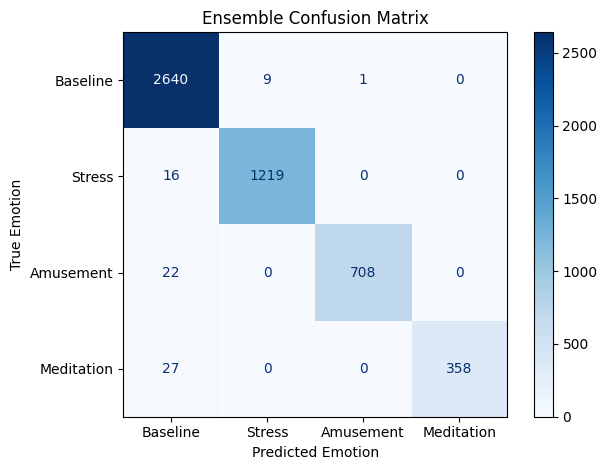

In [1]:
# ============================================================
# ENSEMBLE PIPELINE TEST
# ============================================================
#
# Tests:
#
#   1. Load all trained .pkl models
#   2. Randomly select a WESAD subject/window
#   3. Run predictor
#   4. Test 4 ensemble configurations:
#
#       A. All 6 models - Equal weights
#       B. All 6 models - Performance weights
#       C. 4 models    - Equal weights
#          (without Logistic Regression / KNN)
#       D. 4 models    - Performance weights
#          (without Logistic Regression / KNN)
#
#   5. Compare each ensemble to the true WESAD label
#
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import random
import numpy as np
import json


# ============================================================
# IMPORT PIPELINE
# ============================================================

from inference.model_loader import load_models

from inference.predictor import predict

from inference.ensemble import weighted_ensemble

from pipelines.data_loader import load_all_subjects


# ============================================================
# CONFIGURATION
# ============================================================

DATA_DIR = 'data/WESAD'

WINDOW_SIZE = 400

#RANDOM_SEED = 42

#random.seed(RANDOM_SEED)

#np.random.seed(RANDOM_SEED)


# ============================================================
# CLASS NAMES
# ============================================================

CLASS_NAMES = {

    0: "Baseline",

    1: "Stress",

    2: "Amusement",

    3: "Meditation"
}

prediction_history = []
# ============================================================
# 1. LOAD MODELS
# ============================================================

print("=" * 70)
print("LOADING MODELS")
print("=" * 70)


models, feature_names = load_models()


print(
    f"\nLoaded {len(models)} models:"
)


for name, model in models.items():

    print(
        f"  ✓ {name:<22} "
        f"{type(model).__name__}"
    )


# ============================================================
# 2. LOAD WESAD
# ============================================================

print("\n" + "=" * 70)
print("LOADING WESAD")
print("=" * 70)


signals, labels = load_all_subjects(
    DATA_DIR
)


print(
    f"\nSubjects loaded: "
    f"{len(signals)}"
)



true_labels = []
ensemble_predictions = []


for i in range (5000):
    # ============================================================
    # 3. RANDOMLY SELECT A SUBJECT
    # ============================================================

    valid_subjects = []


    for subject_index, signal in enumerate(signals):

        if len(signal) >= WINDOW_SIZE:

            valid_subjects.append(
                subject_index
            )


    if not valid_subjects:

        raise ValueError(
            "No subjects contain enough samples "
            "for a 400-sample window."
        )


    subject_index = random.choice(
        valid_subjects
    )


    signal = signals[
        subject_index
    ]

    label = labels[
        subject_index
    ]

    # ============================================================
    # FIND WINDOWS CONTAINING X-Emotion
    # ============================================================
    '''
    STRESS_LABEL = 3
    WINDOW_SIZE = 400

    valid_windows = []

    for subject_index, (signal, label) in enumerate(
        zip(signals, labels)
    ):

        # Find possible windows
        for start_index in range(
            0,
            len(signal) - WINDOW_SIZE + 1,
            50
        ):

            label_window = label[
                start_index:
                start_index + WINDOW_SIZE
            ]

            # Majority label of window
            window_label = int(
                np.bincount(
                    label_window.astype(int)
                ).argmax()
            )

            # Keep ONLY stress windows
            if window_label != 0:

                valid_windows.append(
                    (subject_index, start_index)
                )


    print(
        f"Found {len(valid_windows)} "
        f"stress windows."
    )


    # ============================================================
    # RANDOMLY SELECT ONE STRESS WINDOW
    # ============================================================

    subject_index, start_index = random.choice(
        valid_windows
    )


    signal = signals[subject_index]
    label = labels[subject_index]


    sensor_window = signal[
        start_index:
        start_index + WINDOW_SIZE
    ]


    label_window = label[
        start_index:
        start_index + WINDOW_SIZE
    ]


    true_label = int(
        np.bincount(
            label_window.astype(int)
        ).argmax()
    )


    true_emotion = CLASS_NAMES[
        true_label
    ]


    print("\nSelected stress window:")
    print(
        f"Subject:      {subject_index}"
    )
    print(
        f"Start index:  {start_index}"
    )
    print(
        f"True label:   {true_label}"
    )
    print(
        f"True emotion: {true_emotion}"
    )
    '''
    # ============================================================
    # 4. RANDOMLY SELECT A WINDOW
    # ============================================================
    
    max_start = (
        len(signal)
        - WINDOW_SIZE
    )


    start_index = random.randint(
        0,
        max_start
    )


    sensor_window = signal[
        start_index:
        start_index + WINDOW_SIZE
    ]


    label_window = label[
        start_index:
        start_index + WINDOW_SIZE
    ]


    # Majority label = true label
    true_label = int(
        np.bincount(
            label_window.astype(int)
        ).argmax()
    )


    true_emotion = CLASS_NAMES.get(
        true_label,
        str(true_label)
    )

    '''
    print("\n" + "=" * 70)
    print("RANDOM TEST WINDOW")
    print("=" * 70)


    print(
        f"\nSubject:       {subject_index}"
    )

    print(
        f"Start index:   {start_index}"
    )

    print(
        f"Window size:   {WINDOW_SIZE}"
    )

    print(
        f"Window shape:  {sensor_window.shape}"
    )

    print(
        f"True label:    {true_label}"
    )

    print(
        f"True emotion:  {true_emotion}"
    )

    '''
    # ============================================================
    # 5. RUN PREDICTOR
    # ============================================================


    prediction_result = predict(
        sensor_window
    )
    
    


    # ============================================================
    # PRINT INDIVIDUAL PREDICTIONS
    # ============================================================
    '''
    print("\nINDIVIDUAL MODEL PREDICTIONS")
    print("-" * 70)


    for model_name, prediction in (
        prediction_result["predictions"].items()
    ):

        correct = (
            prediction == true_emotion
        )

        status = "✓" if correct else "✗"


        print(
            f"{status} "
            f"{model_name:<22} "
            f"→ {prediction}"
        )

    '''
    # ============================================================
    # 6. PRINT MODEL PROBABILITIES
    # ============================================================
    '''
    print("\n" + "=" * 70)
    print("MODEL PROBABILITIES")
    print("=" * 70)


    for model_name, probabilities in (
        prediction_result["probabilities"].items()
    ):

        print(
            f"\n{model_name}"
        )

        print("-" * 40)


        if probabilities is None:

            print(
                "No probability output."
            )

            continue


        for emotion, probability in (
            probabilities.items()
        ):

            print(
                f"  {emotion:<12} "
                f"{probability:.4f}"
            )

    '''
    # ============================================================
    # 7. DEFINE ENSEMBLE WEIGHTS
    # ============================================================
    #
    # IMPORTANT:
    #
    # These performance weights are INITIAL weights.
    #
    # Replace them later with the actual validation
    # performance of your trained models.
    #
    # ============================================================

    # ------------------------------------------------------------

    performance_weights_all = {

        "XGBoost": 0.965,

        "Random Forest": 0.865,

        "Gradient Boosting": 0.70,

        "SVM": 0.41,

        "Logistic Regression": 0.14,

        "KNN": 0.32
    }


    


    # ============================================================
    # 9. RUN ENSEMBLE CONFIGURATIONS
    # ============================================================

    ensemble_configs = {
        "All 6 - Performance Weighted": (
            prediction_result["probabilities"],
            performance_weights_all
        )
    }


    ensemble_results = {}


    # ============================================================
    # 10. RUN EACH ENSEMBLE
    # ============================================================



    for ensemble_name, (
        probabilities,
        weights
    ) in ensemble_configs.items():


        result = weighted_ensemble(

            probabilities,

            weights
        )


        ensemble_results[
            ensemble_name
        ] = result


        prediction = result[
            "prediction"
        ]


        confidence = result[
            "confidence"
        ]


        
        true_labels.append(true_emotion)
        ensemble_predictions.append(prediction)

        correct = (
            prediction == true_emotion
        )


        status = (
            "✓ CORRECT"
            if correct
            else "✗ WRONG"
        )

        '''
        print(
            f"\n{ensemble_name}"
        )

        print(
            f"  Prediction: "
            f"{prediction}"
        )

        print(
            f"  Confidence: "
            f"{confidence:.4f}"
        )

        print(
            f"  Result: "
            f"{status}"
        )


        print(
            "\n  Probabilities:"
        )


        for emotion, probability in (
            result["probabilities"].items()
        ):

            print(
                f"    {emotion:<12} "
                f"{probability:.4f}"
            )
        '''

    # ============================================================
    # 11. SUMMARY TABLE
    # ============================================================


    '''
    print(
        f"\n{'Configuration':<35}"
        f"{'Prediction':<15}"
        f"{'Confidence':<12}"
        f"Correct"
    )
    '''
    


    for ensemble_name, result in (
        ensemble_results.items()
    ):

        prediction = result[
            "prediction"
        ]

        confidence = result[
            "confidence"
        ]

        correct = (
            prediction == true_emotion
        )

        '''
        print(
            f"{ensemble_name:<35}"
            f"{prediction:<15}"
            f"{confidence:<12.4f}"
            f"{'YES' if correct else 'NO'}"
        )
        '''

    # ============================================================
    # 12. PRINT FULL JSON OUTPUT
    # ============================================================
    #
    # This is approximately what we will eventually send
    # into the Ollama reasoning layer.
    #
    # ============================================================
    


    final_test_output = {

        "test_window": {

            "subject":
                int(subject_index),

            "start_index":
                int(start_index),

            "window_size":
                int(WINDOW_SIZE),

            "true_label":
                true_label,

            "true_emotion":
                true_emotion
        },


        "model_predictions":
            prediction_result[
                "predictions"
            ],


        "model_probabilities":
            prediction_result[
                "probabilities"
            ],


        "ensemble_results":
            ensemble_results,

        "prediction_history":
            prediction_history[:-6]
    }

    prediction_history.append(
        ensemble_results
    )
    # ============================================================
    # 13. BASIC VALIDATION
    # ============================================================


    assert len(models) == 6, (
        "Expected 6 trained models."
    )


    assert sensor_window.shape[0] == 400, (
        "Expected 400 samples."
    )


    assert sensor_window.shape[1] >= 6, (
        "Expected at least 6 sensor columns."
    )


    assert len(
        prediction_result["predictions"]
    ) == 6, (
        "Expected predictions from all 6 models."
    )


    assert len(
        prediction_result["probabilities"]
    ) == 6, (
        "Expected probability output from all 6 models."
    )


    for ensemble_name, result in (
        ensemble_results.items()
    ):

        assert "prediction" in result

        assert "confidence" in result

        assert "probabilities" in result


  

# ============================================================
# CONFUSION MATRIX
# ============================================================

labels = [
    "Baseline",
    "Stress",
    "Amusement",
    "Meditation"
]

cm = confusion_matrix(
    true_labels,
    ensemble_predictions,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Ensemble Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.tight_layout()
plt.show()

In [4]:
import numpy as np
import requests

sensor_window = np.random.rand(200, 6).tolist()

import requests



response = requests.post(
    "http://127.0.0.1:8000/predict",
    json={
        "data": sensor_window
    }
)

print("Status:", response.status_code)
print("Content-Type:", response.headers.get("content-type"))
print("Raw response:")
print(response.text)

if response.headers.get("content-type", "").startswith("application/json"):
    print("\nJSON:")
    print(response.json())

print(sensor_window)

Status: 200
Content-Type: application/json
Raw response:
{"prediction":"Baseline","confidence":0.4779812864524039,"models":{"predictions":{"XGBoost":"Baseline","Random Forest":"Meditation","SVM":"Baseline","Logistic Regression":"Baseline","KNN":"Amusement","Gradient Boosting":"Baseline"},"probabilities":{"XGBoost":{"Baseline":0.5471509099006653,"Stress":0.31297948956489563,"Amusement":0.017037108540534973,"Meditation":0.1228325217962265},"Random Forest":{"Baseline":0.285,"Stress":0.15,"Amusement":0.22,"Meditation":0.345},"SVM":{"Baseline":0.6559463695893618,"Stress":0.13717679619448384,"Amusement":0.12997966592888785,"Meditation":0.07689716828726655},"Logistic Regression":{"Baseline":0.9327408045114868,"Stress":3.6608143669984807e-10,"Amusement":0.06725911438843336,"Meditation":8.07339984661523e-08},"KNN":{"Baseline":0.20245902986388034,"Stress":0.0,"Amusement":0.7975409701361197,"Meditation":0.0},"Gradient Boosting":{"Baseline":0.6101657039137667,"Stress":0.03141499744998123,"Amusemen

In [1]:
import pickle
import json
import numpy as np
from scipy.signal import resample

# =========================
# SETTINGS
# =========================

WESAD_FILE = 'data/WESAD/S4.pkl'

WINDOW_SIZE = 200
WINDOW_START = 0

OUTPUT_FILE = "wesad_test_window_1.json"


# =========================
# LOAD WESAD
# =========================

with open(WESAD_FILE, "rb") as f:
    data = pickle.load(f, encoding="latin1")

wrist = data["signal"]["wrist"]

eda = wrist["EDA"].flatten()
bvp = wrist["BVP"].flatten()
temp = wrist["TEMP"].flatten()
acc = wrist["ACC"]


# =========================
# RESAMPLE
# Same process as load_subject()
# =========================

target_len = len(eda)

bvp = resample(bvp, target_len)

acc_x = resample(acc[:, 0], target_len)
acc_y = resample(acc[:, 1], target_len)
acc_z = resample(acc[:, 2], target_len)


# =========================
# COMBINE
# =========================

combined = np.column_stack([
    eda,
    bvp,
    temp,
    acc_x,
    acc_y,
    acc_z
])


# =========================
# SELECT WINDOW
# =========================

window = combined[
    WINDOW_START:WINDOW_START + WINDOW_SIZE
]


if len(window) != WINDOW_SIZE:
    raise ValueError(
        f"Only found {len(window)} samples. "
        f"Need {WINDOW_SIZE}."
    )


# =========================
# EXPORT
# =========================

output = {
    "data": window.tolist()
}

with open(OUTPUT_FILE, "w") as f:
    json.dump(output, f, indent=2)


print(f"Exported: {OUTPUT_FILE}")
print(f"Shape: {window.shape}")
print("Columns: EDA, BVP, TEMP, ACC_X, ACC_Y, ACC_Z")

Exported: wesad_test_window_1.json
Shape: (200, 6)
Columns: EDA, BVP, TEMP, ACC_X, ACC_Y, ACC_Z
